# Synthetic Ground-Truth Training

Validation experiment: generate a voltage trace from **known** AdEx parameters,
then attempt to recover those parameters via gradient-based training.

This isolates the training pipeline from experimental noise — if training works here,
any failure on real data points to data/model mismatch rather than pipeline bugs.

**Setup:**
- Ground truth parameters: Naud "adaptation" set (configurable)
- Current stimulus: reuses experimental current waveform for realism
- Initial parameters: small perturbation (~15%) from ground truth
- Two-stage training: Stage 1 (Guarino, coarse) → Stage 2 (fine-tune adaptation)

In [10]:
import logging
import time

import jax
import jax.numpy as jnp
import jax.random as jr
import optax
from jax import config
from jaxley.optimize.utils import l2_norm

from ADoptEX.core.data import TraceData, crop_to_stim_window, detect_spikes, load_trace
from ADoptEX.core.parameters import DEFAULT_PARAMS, NAUD_PARAMETERS, PARAM_BOUNDS
from ADoptEX.core.simulation import simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import (
    VanRossumLossConfig,
    make_van_rossum_loss_fn,
)
from ADoptEX.plotting import (
    fit_before_after_plot,
    fit_comparison_plot,
    parameter_comparison_plot,
    spike_timing_plot,
    trace_stim_window_plot,
)
from ADoptEX.training import (
    TrainingResult,
    setup_trainable_cell,
    build_param_transform,
    nudge_from_bounds, TrainingConfig,
)

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")

SEED = 42

## 1. Ground Truth Parameters & Current Stimulus

Load the experimental current waveform (for realistic stimulus shape),
then define ground truth AdEx parameters.

In [11]:
# --- Load experimental current waveform (we only use the current, not the voltage) ---
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"

exp_trace = load_trace(
    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_553.dat",
    current_path=DATA_DIR + "ECBL_IDthresh_ch4_553.dat",
)
exp_cropped = crop_to_stim_window(exp_trace, max_duration_ms=195.0, padding_ms_before=5)

print(f"Current waveform: {exp_cropped.n_samples} samples, dt={exp_cropped.dt_ms:.3f} ms")
print(f"Stim window: idx {exp_cropped.stim_start_idx} - {exp_cropped.stim_end_idx} ({exp_cropped.stim_duration_ms:.1f} ms)")
print(f"Stim current: {exp_cropped.stim_current_pA:.1f} pA")

Current waveform: 2000 samples, dt=0.100 ms
Stim window: idx 50 - 2000 (195.0 ms)
Stim current: 421.3 pA


In [12]:
# --- Ground truth parameters (change this to test different regimes) ---
# GROUND_TRUTH_BASE = "adaptation"  # "tonic", "adaptation", or "original"
GROUND_TRUTH_BASE = "tonic"  # "tonic", "adaptation", or "original"

ground_truth_params = dict(NAUD_PARAMETERS[GROUND_TRUTH_BASE])
ground_truth_params["v_threshold"] = 0.0
ground_truth_params["delta_T"] = 3.0

# Override values that would sit at parameter bounds (which prevents perturbation
# and makes recovery trivial/impossible). Choose values well inside PARAM_BOUNDS.
ground_truth_params["v_reset"] = -52.0   # bounds: [-60, -45], midpoint -52.5
ground_truth_params["E_L"] = -72.0       # bounds: [-75, -68], midpoint -71.5
ground_truth_params["v_T"] = -45.0       # bounds: [-60, -30], well inside
ground_truth_params["tau_w"] = 200.0     # bounds: [20, 320], well inside

print(f"Ground truth base: {GROUND_TRUTH_BASE}")
print("Ground truth parameters:")
for k, v in ground_truth_params.items():
    bounds = PARAM_BOUNDS.get(k)
    if bounds:
        pos = (v - bounds.min) / (bounds.max - bounds.min) * 100
        print(f"  {k:<12} {v:>10.3f}  [{bounds.min}, {bounds.max}]  ({pos:.0f}% into range)")
    else:
        print(f"  {k:<12} {v:>10.3f}")

Ground truth base: tonic
Ground truth parameters:
  C_m             200.000  [180.0, 220.0]  (50% into range)
  g_L              10.000  [9.0, 13.0]  (25% into range)
  E_L             -72.000  [-75.0, -68.0]  (43% into range)
  v_T             -45.000  [-60.0, -30.0]  (50% into range)
  delta_T           3.000  [2, 20.0]  (6% into range)
  v_reset         -52.000  [-60.0, -45.0]  (53% into range)
  v_threshold       0.000  [-20.0, 30.0]  (40% into range)
  tau_w           200.000  [20.0, 320.0]  (60% into range)
  a                 2.000  [-10.0, 3.0]  (92% into range)
  b                 0.000  [0.0, 65.0]  (0% into range)
  I               500.000


## 2. Generate Synthetic Voltage Trace

Simulate with ground truth parameters and the experimental current waveform,
then package the result as `TraceData` (same structure as experimental data).

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Ground truth simulation: 10 spikes, 50.0 Hz
Time step length: 0.10 ms

Synthetic TraceData: 2000 samples, 10 spikes
Spike times: [ 32.9  48.7  64.8  81.1  97.7 114.5 131.6 148.9 166.4 184.1] ms
Stim window: idx 50 - 2000 (195.0 ms)


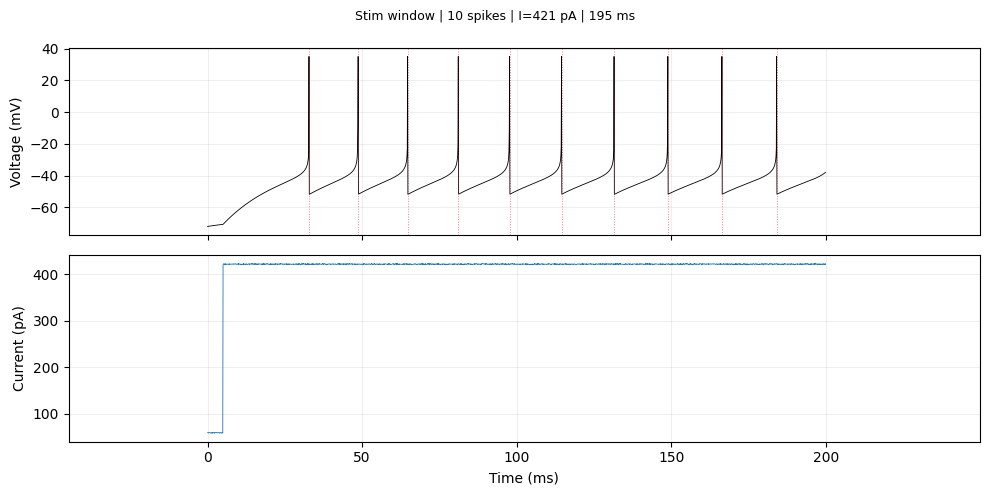

In [13]:
# --- Simulate ground truth ---
# IMPORTANT: use_surrogate=True so the forward pass matches the training cell exactly.
# AdEx uses jax.lax.select (boolean), AdExSurrogate uses arithmetic blend (s*a + (1-s)*b).
# Even though both produce 0/1 spikes, floating-point differences accumulate over 4000
# timesteps and cause a significant loss floor if mismatched.
sim_gt = simulate_with_current_trace(
    params=ground_truth_params,
    current_trace_pA=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    use_surrogate=True,
    surrogate_type="sigmoid",
    surrogate_slope=5.0,
)

print(f"Ground truth simulation: {sim_gt.n_spikes} spikes, {sim_gt.firing_rate_hz:.1f} Hz")

# --- Package as TraceData (same structure as experimental data) ---
# Jaxley may return one extra timestep; truncate to match the input current length
n = len(exp_cropped.time)
voltage_gt = sim_gt.voltage[:n].copy()

# Use spike times from the simulation's internal spike trace, NOT from detect_spikes().
# Jaxley resets voltage within the same timestep, so the recorded voltage never crosses
# the detection threshold — but the spike indicator is set correctly.
spike_times = sim_gt.spike_times

# Inject spike peaks into the voltage trace at known spike times.
# Jaxley's same-timestep reset means recorded voltage never shows the spike peak.
# Real experimental recordings show full peaks, so we restore them to make the
# synthetic data look like experimental data for feature extraction.
#
# IMPORTANT: This value must match the spike_peak_mv used in loss functions
# (e.g. MSELossConfig) to avoid an artificial loss floor from peak amplitude mismatch.
SPIKE_PEAK_MV = 35.0
for st in spike_times:
    idx = int(st / exp_cropped.dt_ms)
    if 0 <= idx < len(voltage_gt):
        voltage_gt[idx] = SPIKE_PEAK_MV

data = TraceData(
    time=exp_cropped.time,
    voltage=voltage_gt,
    current=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    spike_times=spike_times,
    stim_start_idx=exp_cropped.stim_start_idx,
    stim_end_idx=exp_cropped.stim_end_idx,
    stim_current_pA=exp_cropped.stim_current_pA,
)

print(f"Time step length: {data.dt_ms:.2f} ms")
print(f"\nSynthetic TraceData: {data.n_samples} samples, {data.n_spikes} spikes")
print(f"Spike times: {data.spike_times.round(1)} ms")
print(f"Stim window: idx {data.stim_start_idx} - {data.stim_end_idx} ({data.stim_duration_ms:.1f} ms)")

trace_stim_window_plot(data);

## 3. Perturbed Initial Parameters

Create initial parameters by adding ~15% noise to the ground truth.
This simulates the real scenario where we don't know the true values.

In [14]:
PERTURBATION = 0.15  # relative perturbation

# C_m, g_L, E_L, v_T, delta_T, v_reset, v_threshold, tau_w, a, b
TRAINABLE_STAGE1 = ["g_L", "v_reset", "v_T", "E_L", "delta_T"]
# TRAINABLE_STAGE1 = ["C_m"]

def perturb_params(
    params: dict,
    trainable: list[str],
    perturbation: float,
    key: jax.Array,
) -> dict:
    """Add relative noise to trainable params, clipping to PARAM_BOUNDS."""
    perturbed = dict(params)
    keys = jr.split(key, len(trainable))
    for k, name in zip(keys, trainable):
        val = params[name]
        bounds = PARAM_BOUNDS[name]
        # Scale noise by parameter range to handle params near zero (e.g. a=0)
        param_range = bounds.max - bounds.min
        noise = float(jr.uniform(k, minval=-perturbation, maxval=perturbation))
        perturbed[name] = bounds.clip(val + noise * param_range)
    return perturbed


all_trainable = list(set(TRAINABLE_STAGE1))
initial_params = perturb_params(
    ground_truth_params, all_trainable, PERTURBATION, jr.PRNGKey(SEED)
)

# initial_params = ground_truth_params

print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Error':>8}")
print("-" * 48)
for k in all_trainable:
    gt = ground_truth_params[k]
    init = initial_params[k]
    bounds = PARAM_BOUNDS[k]
    err_pct = abs(init - gt) / (bounds.max - bounds.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {err_pct:>7.1f}%")

Parameter    Ground Truth      Initial    Error
------------------------------------------------
v_T               -45.000      -44.728     0.9%
E_L               -72.000      -71.522     6.8%
v_reset           -52.000      -51.247     5.0%
g_L                10.000        9.867     3.3%
delta_T             3.000        4.316     7.3%


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.


/Users/paulmayer/Projects/university/40_thesis/3_jaxley/jaxley/channels/non_capacitive/adex.py:82: UserWarning: The AdEx channel does not support surrogate gradients. Its gradient will be zero after every spike. Use AdExSurrogate for differentiable spiking.
  warn(


Initial simulation: 10 spikes (target: 10)
Gamma = 0.152


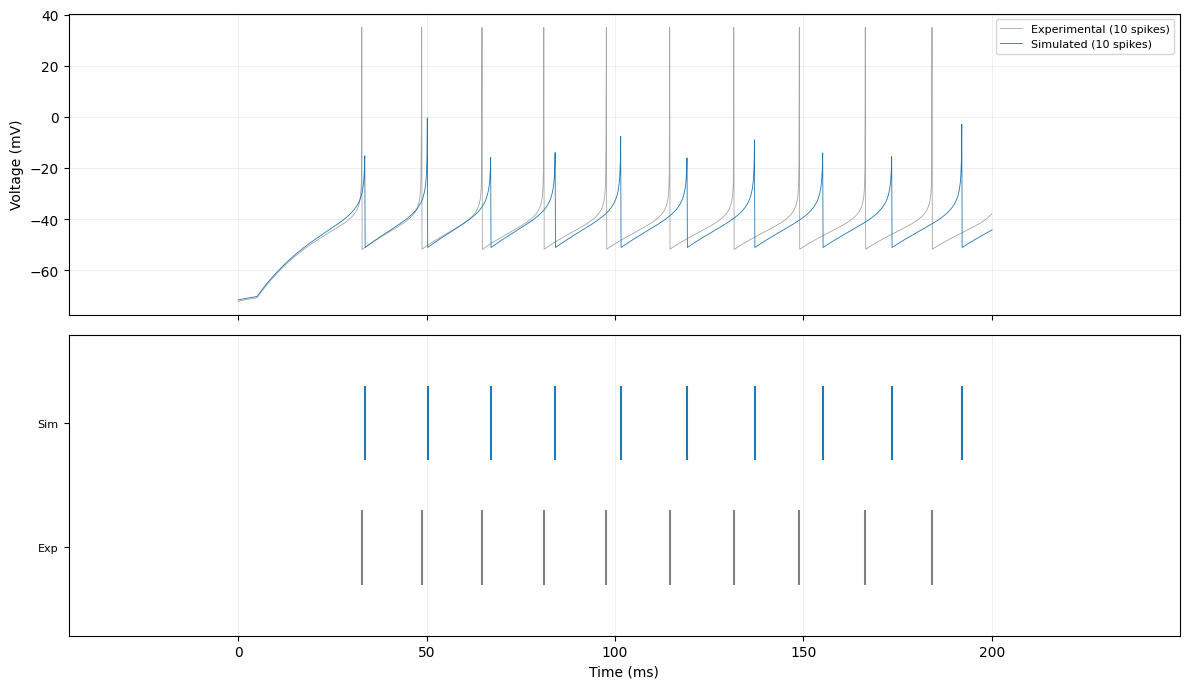

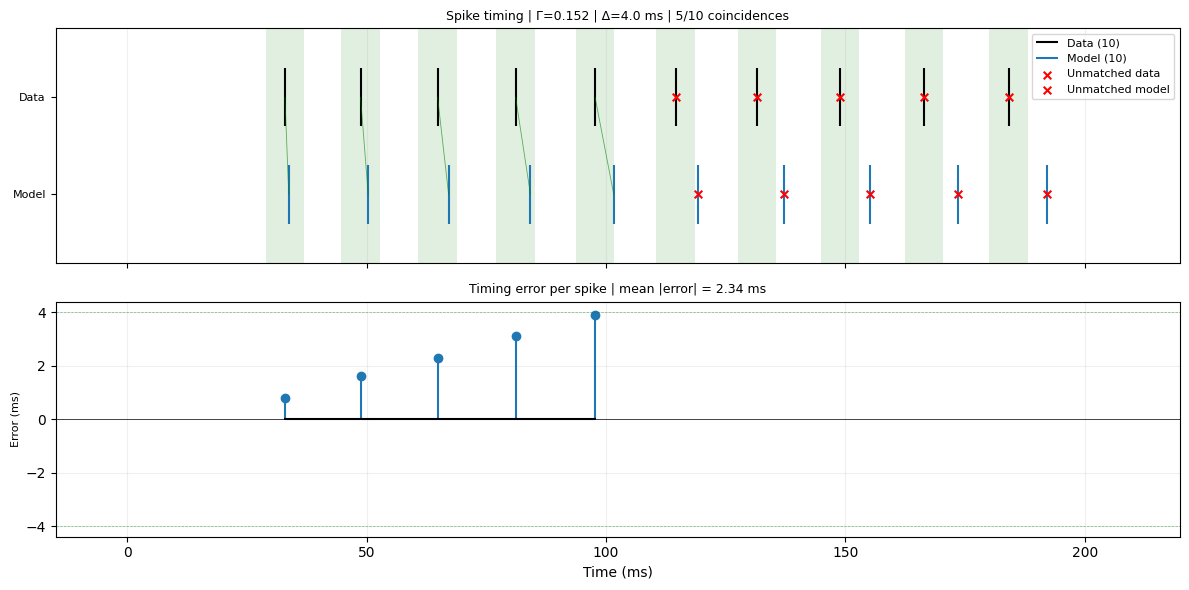

In [15]:
# Simulate with perturbed initial parameters to see the starting point
sim_init = simulate_with_current_trace(
    params=initial_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=False,
)

print(f"Initial simulation: {sim_init.n_spikes} spikes (target: {data.n_spikes})")


if sim_init.n_spikes > 0 and data.n_spikes > 0:
    cf_s0 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_init.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=4,
    )
    print(f"Gamma = {cf_s0.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_init);

if cf_s0 is not None:
    spike_timing_plot(data, sim_init, cf_s0);


## 4. Stage 1 — Van Rossum Distance (Spike Train Matching)

In [16]:
training_config = TrainingConfig(
    optimizer="polyak",
    learning_rate=0.001,
    n_epochs=50,
    surrogate_type="sigmoid",
    surrogate_slope=2.0,
    print_every=5,
    polyak_alpha=1.0,
    polyak_beta=0.85,
    clip_to_bounds=False,
    use_param_transform=True,
    verbose=True,
    return_best=True,
)

# Create trainable cell
cell1, data_stimuli1, t_max1, trainable_params1 = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    config = training_config,
    trainable_params=TRAINABLE_STAGE1,
)

# Build target spike train from ground truth simulation's spike trace.
# Use the raw Jaxley spike indicator (not voltage threshold crossing) so the
# target exactly matches what the training cell can produce.
n = min(len(sim_gt.spikes), data.stim_end_idx + 100)
exp_spike_train = jnp.array(sim_gt.spikes[:n])

print(f"Target spike train: {int(exp_spike_train.sum())} spikes in {n} timesteps")

loss_fn_stage1 = make_van_rossum_loss_fn(
    cell=cell1,
    data_stimuli=data_stimuli1,
    t_max=t_max1,
    dt_ms=data.dt_ms,
    exp_spike_train=exp_spike_train,
    exp_voltage=voltage_gt,
    stim_end_index=data.stim_end_idx,
    loss_config=VanRossumLossConfig(
        tau_ms=15.0,
        weight_subthreshold=0.5,
        subthreshold_clamp_mv=-40
    ),
)

print(f"Initial Van Rossum loss: {float(loss_fn_stage1(trainable_params1)):.4f}")

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Target spike train: 10 spikes in 2001 timesteps
Initial Van Rossum loss: 3.6857


In [17]:
# --- Sigmoid reparameterization ---
param_transform = build_param_transform(trainable_params1, PARAM_BOUNDS)
trainable_params1 = nudge_from_bounds(trainable_params1, PARAM_BOUNDS)
opt_params = param_transform.inverse(trainable_params1)

# Wrap loss to work in unconstrained space
loss_fn = lambda p: loss_fn_stage1(param_transform.forward(p))
grad_fn = jax.jit(jax.value_and_grad(loss_fn))

# Polyak SGD
n_epochs = 50
mu = 0.005 * l2_norm(jnp.ones(len(opt_params)))
beta = 0.8

optimizer = optax.inject_hyperparams(optax.sgd)(learning_rate=mu)
opt_state = optimizer.init(opt_params)

loss_history, grad_norms, lr_history, time_per_epoch = [], [], [], []
best_loss, best_params, best_epoch = float("inf"), None, -1

for epoch in range(n_epochs):
    t0 = time.time()
    loss_val, grad_val = grad_fn(opt_params)

    if jnp.isnan(loss_val) or jnp.isinf(loss_val):
        print(f"NaN/Inf at epoch {epoch}"); break

    norm = l2_norm(grad_val)**beta + 1e-8
    grad_val = jax.tree.map(lambda g: g / norm, grad_val)

    lr = loss_val * mu
    opt_state.hyperparams["learning_rate"] = lr

    updates, opt_state = optimizer.update(grad_val, opt_state)
    opt_params = optax.apply_updates(opt_params, updates)

    # Track
    loss_history.append(float(loss_val)); grad_norms.append(float(norm))
    lr_history.append(float(lr))
    time_per_epoch.append(time.time() - t0)

    if abs(float(loss_val)) < abs(best_loss):
        best_loss, best_params, best_epoch = float(loss_val), opt_params, epoch

    if epoch % 5 == 0:
        print(f"Epoch {epoch:4d} | loss={float(loss_val):.6f} | grad norm={float(norm):.2e}")

# Package result
final_params = param_transform.forward(best_params if best_params is not None else opt_params)
result_stage1 = TrainingResult(
    trainable_params=final_params, loss_history=loss_history,
    time_per_epoch=time_per_epoch, initial_params=initial_params,
    grad_norms=grad_norms, lr_history=lr_history, best_epoch=best_epoch,
    label="polyak sigmoid van_rossum tau=10ms",
)

print(f"\nStage 1 complete.")
print(f"  Best loss:   {result_stage1.best_loss:.4f} in epoch {result_stage1.best_epoch}")
print(f"  Total time:  {result_stage1.total_time:.1f} s")

Epoch    0 | loss=3.685735 | grad norm=8.61e+05
Epoch    5 | loss=4.568501 | grad norm=1.77e+01
Epoch   10 | loss=3.974951 | grad norm=4.21e+02
Epoch   15 | loss=219.494476 | grad norm=inf
Epoch   20 | loss=219.494476 | grad norm=inf
Epoch   25 | loss=219.494476 | grad norm=inf
Epoch   30 | loss=219.494476 | grad norm=inf
Epoch   35 | loss=219.494476 | grad norm=inf
Epoch   40 | loss=219.494476 | grad norm=inf
Epoch   45 | loss=219.494476 | grad norm=inf

Stage 1 complete.
  Best loss:   1.7606 in epoch 11
  Total time:  0.8 s


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Stage 1: 10 spikes (target: 10)
Gamma = 0.491


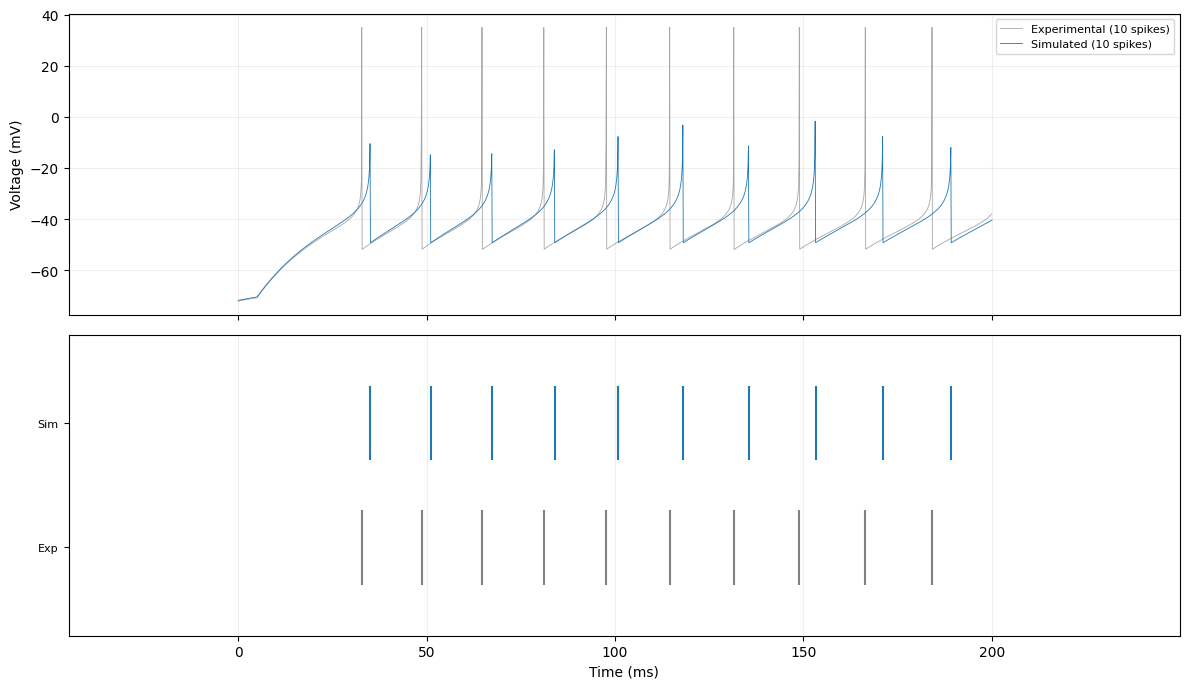

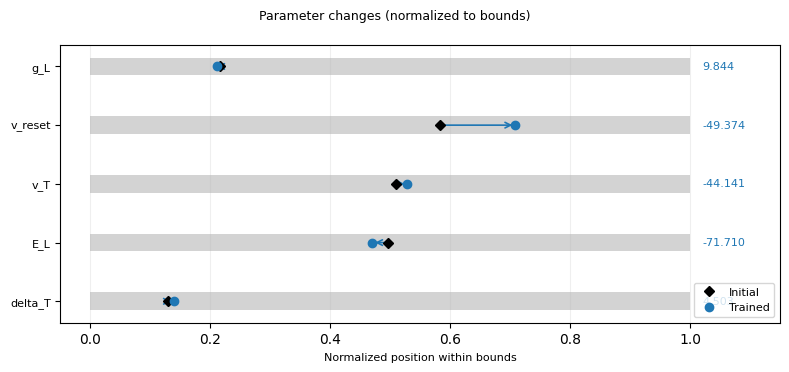

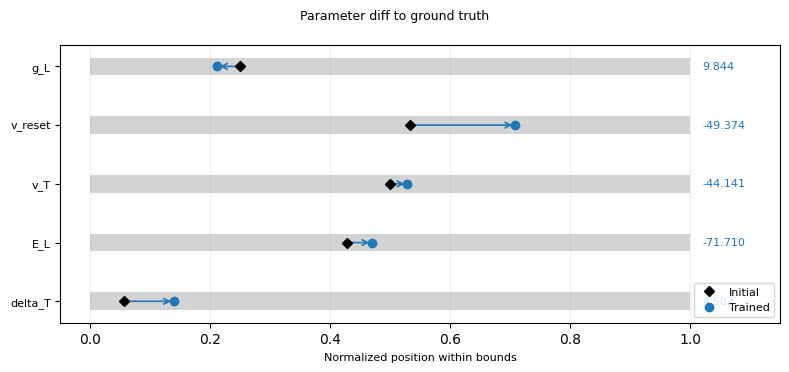

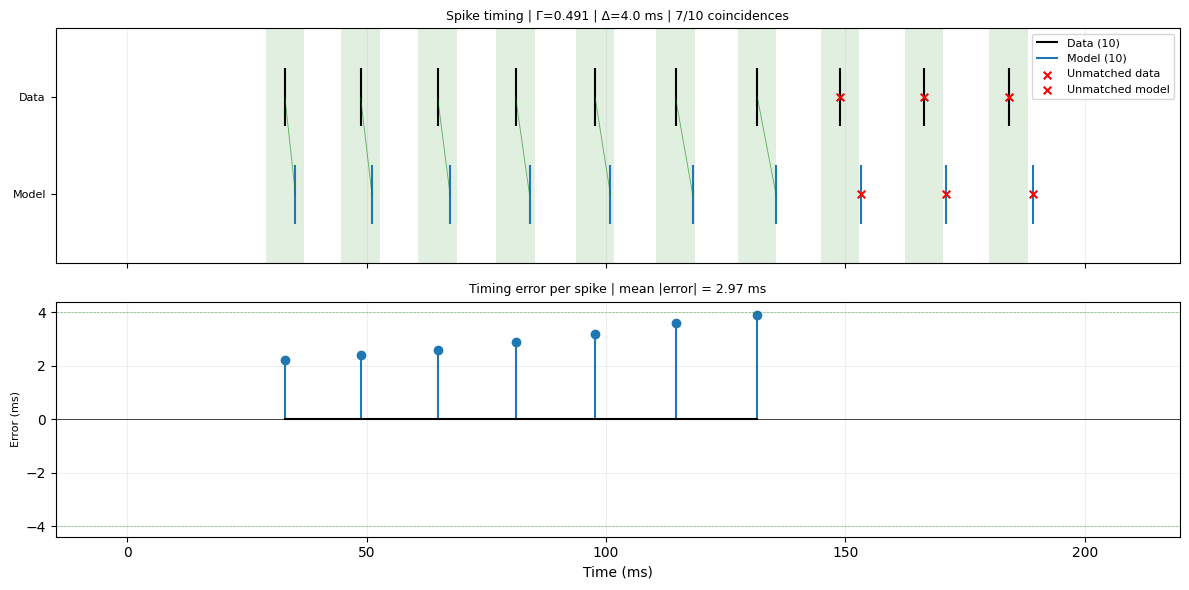

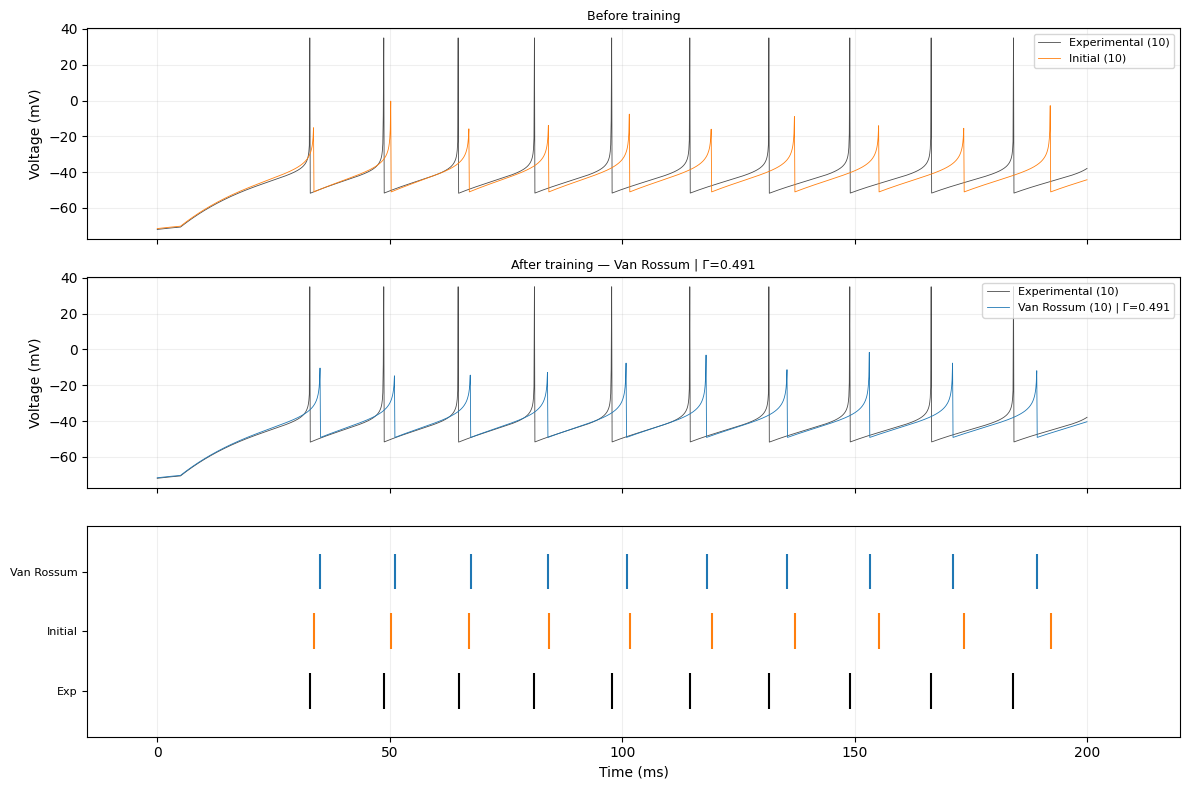

In [18]:
# Evaluate stage 1
params_after_s1 = dict(initial_params)
params_after_s1.update(result_stage1.get_params_dict())

sim_stage1 = simulate_with_current_trace(
    params=params_after_s1,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=True,
)

print(f"Stage 1: {sim_stage1.n_spikes} spikes (target: {data.n_spikes})")

if sim_stage1.n_spikes > 0 and data.n_spikes > 0:
    cf_s1 = coincidence_factor(
        spike_times_data=data.spike_times,
        spike_times_model=sim_stage1.spike_times,
        duration_ms=data.stim_duration_ms,
        delta_ms=4,
    )
    print(f"Gamma = {cf_s1.gamma:.3f}")
else:
    cf_s1 = None
    print("Gamma: N/A (no spikes)")

fit_comparison_plot(data, sim_stage1)
parameter_comparison_plot(result_stage1);
parameter_comparison_plot(TrainingResult(
    trainable_params=result_stage1.trainable_params,
    loss_history=result_stage1.loss_history,
    time_per_epoch=result_stage1.time_per_epoch,
    initial_params=ground_truth_params), figtitle="Parameter diff to ground truth");

if cf_s1 is not None:
    spike_timing_plot(data, sim_stage1, cf_s1);

fit_before_after_plot(
    data,
    sim_init,
    [sim_stage1],
    coincidence=[cf_s1],
    labels=["Van Rossum"],
);